<a href="https://colab.research.google.com/github/hailam1714/Machine_Learning_VLU/blob/main/HMUD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 1: đọc tệp dữ liệu và nhìn qua một lượt.
Chú thích trong tệp viết tiếng Việt có dấu, nhưng phần in ra màn hình cố ý
viết không dấu. Cửa sổ lệnh Windows thường không hiện được chữ có dấu.
"""

import pandas as pd

# Đọc tệp CSV thành một bảng. Tên df là viết tắt quen dùng của data frame.
df = pd.read_csv("gia_nha.csv")
print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("Ten cac cot:", list(df.columns))
print()

print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()

print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


In [8]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 2: đo xem một đường thẳng dự đoán sai bao nhiêu.

Chỉ lấy 5 căn cho dễ nhìn. Thử hai đường thẳng khác nhau rồi so sai số
trung bình bình phương của từng đường.
"""

import pandas as pd

df = pd.read_csv("gia_nha.csv")

# Lấy 5 căn trải đều từ nhỏ nhất tới lớn nhất, không lấy 5 căn đầu bảng
# vì chúng có diện tích gần bằng nhau nên nhìn không rõ.
nho = df.iloc[[0, 14, 29, 44, 59]]

x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()

def mse(w, b):
  """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
  y_du_doan = w * x + b
  sai_so = y - y_du_doan
  return (sai_so ** 2).mean()

print("Nam can duoc chon:")
for i in range(5):
  print(f" {x[i]:6.1f} m2 ‐> {y[i]:5.2f} ty")
print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
  print(f"Duong thang y = {w} * x + {b}")
  for i in range(5):
    du_doan = w * x[i] + b
    sai_so = y[i] - du_doan
    print(f" x = {x[i]:6.1f} that = {y[i]:5.2f}"
          f" du doan = {du_doan:5.2f} sai so = {sai_so:+6.2f}")
  print(f" MSE = {mse(w, b):.4f}")
  print()

print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon.")

Nam can duoc chon:
   35.5 m2 ‐>  3.00 ty
   61.3 m2 ‐>  4.56 ty
   74.2 m2 ‐>  7.17 ty
   91.3 m2 ‐>  7.83 ty
  115.9 m2 ‐>  9.01 ty

Duong thang y = 0.05 * x + 1.5
 x =   35.5 that =  3.00 du doan =  3.28 sai so =  -0.28
 x =   61.3 that =  4.56 du doan =  4.56 sai so =  -0.00
 x =   74.2 that =  7.17 du doan =  5.21 sai so =  +1.96
 x =   91.3 that =  7.83 du doan =  6.07 sai so =  +1.76
 x =  115.9 that =  9.01 du doan =  7.30 sai so =  +1.71
 MSE = 1.9947

Duong thang y = 0.08 * x + 0.5
 x =   35.5 that =  3.00 du doan =  3.34 sai so =  -0.34
 x =   61.3 that =  4.56 du doan =  5.40 sai so =  -0.84
 x =   74.2 that =  7.17 du doan =  6.44 sai so =  +0.73
 x =   91.3 that =  7.83 du doan =  7.80 sai so =  +0.03
 x =  115.9 that =  9.01 du doan =  9.77 sai so =  -0.76
 MSE = 0.3896

Duong nao co MSE nho hon thi duong do khop du lieu tot hon.


In [10]:
 # ‐*‐ coding: utf‐8 ‐*‐
"""Bước 3: tìm w và b tốt nhất bằng công thức, không cần thư viện."""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu cho đường thẳng một biến
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung binh dien tich : {x_tb:.4f}")
print(f"Trung binh gia : {y_tb:.4f}")
print(f"Tu so : {tu_so:.4f}")
print(f"Mau so : {mau_so:.4f}")
print()
print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:.4f}")

# Dự đoán cho một căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich : 77.7317
Trung binh gia : 6.4933
Tu so : 1890.2297
Mau so : 24120.2898

He so goc w = 0.078367
He so chan b = 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018

MSE tren toan bo 60 can: 0.1790
Can 80 m2 duoc du doan: 6.671 ty dong


In [11]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 4: làm lại đúng việc đó bằng scikit‐learn, chỉ mất ba dòng."""

import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("gia_nha.csv")

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
  print(f"Can {dt:.0f} m2 ‐> du doan {gia:.3f} ty dong")

He so goc w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 ‐> du doan 6.671 ty dong
Can 100 m2 ‐> du doan 8.238 ty dong


In [12]:
# -*- coding: utf-8 -*-
"""Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Lưu ý: Nếu bạn dùng Google Colab và đã tải tệp gia_nha.csv lên thư mục gốc,
# hãy giữ nguyên đường dẫn "gia_nha.csv". Nếu để trong thư mục data, hãy dùng "data/gia_nha.csv".
df = pd.read_csv("gia_nha.csv")
X = df[["dien_tich"]]
y = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra.
# random_state cố định để lần nào chia cũng ra đúng một cách chia.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("So can de hoc     :", len(X_train))
print("So can de kiem tra:", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)  # chỉ học trên tập học

y_pred = mo_hinh.predict(X_test)  # chấm điểm trên tập kiểm tra

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f} ty dong")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2   = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    print(
        f"  {dt:6.1f} m2 | that = {that:5.2f} | du doan = {du_doan:5.2f} | sai so = {that - du_doan:+5.2f}"
    )

So can de hoc     : 48
So can de kiem tra: 12

MAE  = 0.2578 ty dong
MSE  = 0.1392
RMSE = 0.3730 ty dong
R2   = 0.9622

Mot vai can trong tap kiem tra:
    35.5 m2 | that =  3.00 | du doan =  3.22 | sai so = -0.22
    50.4 m2 | that =  4.24 | du doan =  4.38 | sai so = -0.14
    82.5 m2 | that =  7.28 | du doan =  6.88 | sai so = +0.40
    93.6 m2 | that =  7.63 | du doan =  7.74 | sai so = -0.11
    59.6 m2 | that =  5.14 | du doan =  5.09 | sai so = +0.05


In [13]:
# -*- coding: utf-8 -*-
"""Bước 6: tự đi tìm w và b bằng cách dò từng bước nhỏ.
Đây là cách máy học khi bài toán không có công thức đóng. Với hồi quy tuyến
tính ta đã có công thức rồi, nên đoạn này chỉ để thấy cơ chế hoạt động.
"""

import numpy as np
import pandas as pd

# Lưu ý: Nếu bạn dùng Google Colab và để tệp gia_nha.csv trong thư mục gốc, hãy dùng "gia_nha.csv"
df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0  # bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1  # mỗi vòng lặp đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x)

print(f"{'Vong':>4s} {'w':>7s} {'b':>7s} {'MSE':>8s}")
for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        # Tính lại MSE bằng w và b VỪA cập nhật, để ba con số trên cùng một
        # dòng bảng đều thuộc về cùng một thời điểm.
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d} {w:7.4f} {b:7.4f} {mse:8.4f}")

print()
# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech
print("Sau khi doi ve thang do met vuong:")
print(f" w = {w_goc:.6f}")
print(f" b = {b_goc:.6f}")
print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")

Vong       w       b      MSE
   1  0.3143  1.2987  28.7437
   2  0.5657  2.3376  18.4604
   5  1.0564  4.3656   4.9714
  10  1.4025  5.7961   0.6936
  25  1.5653  6.4688   0.1797
  50  1.5712  6.4932   0.1790
 100  1.5713  6.4933   0.1790
 200  1.5713  6.4933   0.1790

Sau khi doi ve thang do met vuong:
 w = 0.078367
 b = 0.401752
So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752


In [14]:
# -*- coding: utf-8 -*-
"""Bước 7: dùng thêm số phòng và tuổi nhà, xem mô hình có khá hơn không."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Lưu ý: Nếu bạn để tệp gia_nha.csv ở thư mục gốc của Colab, hãy giữ nguyên "gia_nha.csv"
df = pd.read_csv("gia_nha.csv")
y = df["gia"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien ", X_mot), ("Ba bien ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()

# Xem kỹ các hệ số của mô hình ba biến
X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh.intercept_:+.4f}")

Mot bien : R2 tren tap kiem tra = 0.9622
Ba bien : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
  dien_tich    +0.0701
  so_phong     +0.3042
  tuoi_nha     -0.0295
  he so chan   +0.6917


In [15]:
#Bài tập 1: Lọc ra nhóm căn hộ lớn
# -*- coding: utf-8 -*-

import pandas as pd

# Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")

# Lọc nhóm căn hộ có diện tích lớn hơn 100 m2
nhom_lon = df[df["dien_tich"] > 100]

# In ra kết quả theo yêu cầu
print("So can co dien tich lon hon 100 m2:", len(nhom_lon))
print(f"Gia trung binh cua nhom nay : {nhom_lon['gia'].mean():.3f} ty dong")

So can co dien tich lon hon 100 m2: 10
Gia trung binh cua nhom nay : 8.962 ty dong


Đã lưu biểu đồ thành công vào tệp bai2.png! Nhận xét: Giá nhà có xu hướng tăng khi số phòng ngủ tăng, tuy nhiên độ tản mát lớn hơn so với diện tích vì số phòng chỉ có các giá trị rời rạc (1 đến 4 phòng).


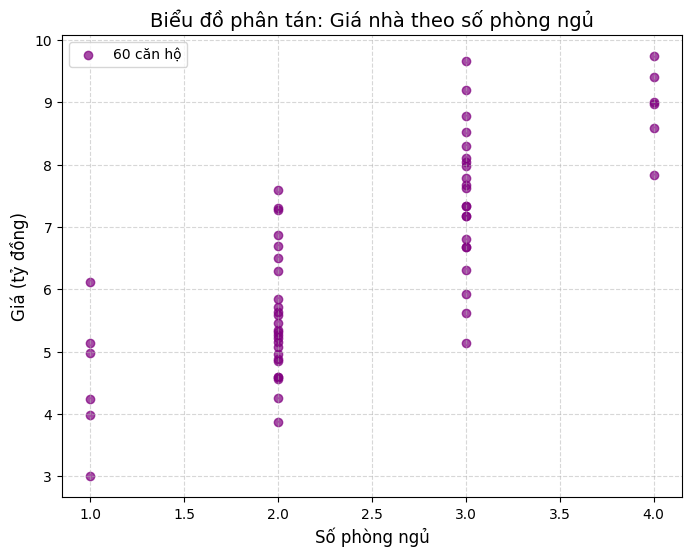

In [16]:
#Bài tập 2: Vẽ biểu đồ phân tán theo số phòng
# -*- coding: utf-8 -*-

import matplotlib.pyplot as plt
import pandas as pd

# Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")

# Vẽ biểu đồ phân tán
plt.figure(figsize=(8, 6))
plt.scatter(
    df["so_phong"], df["gia"], color="purple", alpha=0.7, label="60 căn hộ"
)

# Đặt nhãn trục và tiêu đề
plt.xlabel("Số phòng ngủ", fontsize=12)
plt.ylabel("Giá (tỷ đồng)", fontsize=12)
plt.title("Biểu đồ phân tán: Giá nhà theo số phòng ngủ", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Lưu hình trước khi gọi plt.show()
plt.savefig("bai2.png", dpi=150)
print(
    "Đã lưu biểu đồ thành công vào tệp bai2.png! Nhận xét: Giá nhà có xu hướng tăng khi số phòng ngủ tăng, tuy nhiên độ tản mát lớn hơn so với diện tích vì số phòng chỉ có các giá trị rời rạc (1 đến 4 phòng)."
)

plt.show()

In [19]:
#Bài tập 3: Đổi biến đầu vào sang tuổi nhà
# -*- coding: utf-8 -*-

import pandas as pd

# Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")

# Lấy biến đầu vào x là tuổi nhà, y là giá
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

# Tính trung bình
x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

# In kết quả với 6 chữ số sau dấu phẩy
print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(
    "Nhận xét: Hệ số góc w mang dấu âm. Nghĩa là tuổi nhà càng lớn thì giá bán càng giảm (cũ đi 1 năm thì giá giảm trung bình khoảng 37.9 triệu đồng), điều này hoàn toàn hợp lý với thực tế thị trường bất động sản."
)

He so goc w = -0.037858
He so chan b = 6.983593

Nhận xét: Hệ số góc w mang dấu âm. Nghĩa là tuổi nhà càng lớn thì giá bán càng giảm (cũ đi 1 năm thì giá giảm trung bình khoảng 37.9 triệu đồng), điều này hoàn toàn hợp lý với thực tế thị trường bất động sản.


In [21]:
#Bài tập 4: Thêm số phòng vào mô hình
# -*- coding: utf-8 -*-

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")
X = df[["dien_tich", "so_phong"]]
y = df["gia"]

# Chia tập học và tập kiểm tra theo đúng chuẩn tài liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Huấn luyện mô hình
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

# Dự đoán và tính R2 trên tập kiểm tra
y_pred = mo_hinh.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R2 trên tập kiểm tra (2 biến): {r2:.4f}")
print("So sánh với mô hình 1 biến (R2 = 0.9622)")
print(
    "R2 tăng nhẹ từ 0.9622 lên khoảng 0.9698. Việc thêm cột số phòng giúp mô hình cải thiện độ chính xác một chút, tuy nhiên diện tích đã đóng góp phần lớn sức mạnh dự đoán từ trước."
)

R2 trên tập kiểm tra (2 biến): 0.9698
So sánh với mô hình 1 biến (R2 = 0.9622)
R2 tăng nhẹ từ 0.9622 lên khoảng 0.9698. Việc thêm cột số phòng giúp mô hình cải thiện độ chính xác một chút, tuy nhiên diện tích đã đóng góp phần lớn sức mạnh dự đoán từ trước.


In [23]:
#Bài tập 5: Thử hai tốc độ học khác
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Chuẩn hóa dữ liệu
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech
n = len(x)

# Thử nghiệm 2 tốc độ học
for toc_do_hoc in [0.001, 1.02]:
    w, b = 0.0, 0.0
    so_vong = 200

    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y
        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()

        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b

    mse_cuoi = (((w * x + b) - y) ** 2).mean()
    print(f"Tốc độ học = {toc_do_hoc:5.3f} -> MSE ở vòng 200 = {mse_cuoi:.4f}")

print()
print("Giải thích:")
print(
    "1.Tốc độ học = 0.001: Bước chân dịch chuyển quá ngắn, sau 200 vòng thuật toán chưa kịp lăn xuống đáy thung lũng nên MSE vẫn còn cao."
)
print(
    "2.Tốc độ học = 1.02: Bước chân quá dài khiến mô hình nhảy vọt qua lại qua đáy và văng ra xa hơn, làm sai số phình to bùng nổ theo cấp số nhân."
)

Tốc độ học = 0.001 -> MSE ở vòng 200 = 20.2175
Tốc độ học = 1.020 -> MSE ở vòng 200 = 290391782.0192

Giải thích:
1.Tốc độ học = 0.001: Bước chân dịch chuyển quá ngắn, sau 200 vòng thuật toán chưa kịp lăn xuống đáy thung lũng nên MSE vẫn còn cao.
2.Tốc độ học = 1.02: Bước chân quá dài khiến mô hình nhảy vọt qua lại qua đáy và văng ra xa hơn, làm sai số phình to bùng nổ theo cấp số nhân.


In [25]:
#Bài tập 6: Viết hàm dự đoán có cảnh báo
# -*- coding: utf-8 -*-

# Các hệ số đã học được từ mô hình một biến
w = 0.078367
b = 0.401752


def du_doan_gia(dien_tich):
    # Kiểm tra điều kiện ngoại suy ngoài vùng dữ liệu (35.5 đến 117.5 m2)
    if dien_tich < 35.5 or dien_tich > 117.5:
        print(
            f"Diện tích {dien_tich} m2 nằm ngoài vùng dữ liệu huấn luyện (35.5 - 117.5 m2). Kết quả có thể không đáng tin cậy"
        )

    # Tính giá dự đoán theo công thức tuyến tính
    gia_du_doan = w * dien_tich + b
    return gia_du_doan


# Gọi thử với 3 giá trị diện tích
danh_sach_dien_tich = [60.0, 80.0, 200.0]

for dt in danh_sach_dien_tich:
    ket_qua = du_doan_gia(dt)
    print(f"Diện tích: {dt:5.1f} m2 -> Dự đoán giá: {ket_qua:.3f} tỷ đồng")

Diện tích:  60.0 m2 -> Dự đoán giá: 5.104 tỷ đồng
Diện tích:  80.0 m2 -> Dự đoán giá: 6.671 tỷ đồng
Diện tích 200.0 m2 nằm ngoài vùng dữ liệu huấn luyện (35.5 - 117.5 m2). Kết quả có thể không đáng tin cậy
Diện tích: 200.0 m2 -> Dự đoán giá: 16.075 tỷ đồng
